# CNN paper recreation

This notebook trains the paper's CNN to classify photonic designs as Low or High bandwidth.

In [1]:
# Libraries used in this notebook
import csv
import json
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import callbacks, layers, models

/Users/olzhi/Desktop/Paper replication/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Load the images

Low bandwidth is label 0. High bandwidth is label 1.

In [2]:
PROJECT = "/Users/olzhi/Desktop/Paper replication"
IMAGE_SIZE = 256

folders = {
    "High": f"{PROJECT}/data/combined_high_bw",
    "Low": f"{PROJECT}/data/combined_low_bw",
}

images = []
labels = []
filenames = []

for class_name, folder in folders.items():
    label = 1 if class_name == "High" else 0

    for filename in os.listdir(folder):
        # Ignore files that are not BMP images.
        if not filename.lower().endswith(".bmp"):
            continue

        path = os.path.join(folder, filename)
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        image = image.astype("float32") / 255.0

        images.append(image)
        labels.append(label)
        filenames.append(filename)

# Add the one-channel dimension required by the CNN.
images = np.expand_dims(np.array(images), axis=-1)
labels = np.array(labels)
filenames = np.array(filenames)

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: (221, 256, 256, 1)
Labels: (221,)


## 2. Create the 80/20 split

Use `data/common_split_manifest.csv` so this CNN receives the exact same 176 training and 45 validation images as every other replication model.

In [3]:
with open(f"{PROJECT}/data/common_split_manifest.csv", newline="") as file:
    split_by_file = {row["file"]: row["split"] for row in csv.DictReader(file)}

assert set(filenames) == set(split_by_file), "Dataset and split manifest do not match."
train_mask = np.array([split_by_file[name] == "train" for name in filenames])
validation_mask = np.array([split_by_file[name] == "validation" for name in filenames])
x_train, y_train = images[train_mask], labels[train_mask]
x_validation, y_validation = images[validation_mask], labels[validation_mask]
assert len(x_train) == 176 and len(x_validation) == 45

print("Training images:", len(x_train))
print("Validation images:", len(x_validation))

Training images: 176
Validation images: 45


## 3. Build the CNN

In [4]:
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),

    # Three blocks extract image features.
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # These layers classify the extracted features.
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(2, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,838,658 (56.60 MB)

 Trainable params: 14,838,658 (56.60 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train and evaluate

During training, a callback saves the model weights whenever validation accuracy improves. After all 20 epochs, we reload those best weights into the same CNN architecture and report the best-epoch validation accuracy. There is no independent test set in this comparison.

In [ ]:
# Folder for this run.
results = "/Users/olzh/Documents/Paper replication/model_reproductions/01_cnn_from_scratch"
os.makedirs(results, exist_ok=True)
best_checkpoint_path = f"{results}/best_cnn.weights.h5"

# This callback watches validation accuracy after every epoch.
# It replaces best_cnn.weights.h5 only when the new accuracy is higher.
save_best_model = callbacks.ModelCheckpoint(
    filepath=best_checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
)

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=[save_best_model],
)

# The model variable currently contains the weights from epoch 20.
epoch_20_loss, epoch_20_accuracy = model.evaluate(x_validation, y_validation, verbose=0)
model.save_weights(f"{results}/cnn_epoch_20.weights.h5")

# Locate the best epoch in the recorded history.
best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1

# Reload the weights that the callback saved at the best epoch.
# The model architecture stays the same; only its learned numbers change.
model.load_weights(best_checkpoint_path)
best_validation_loss, best_validation_accuracy = model.evaluate(
    x_validation, y_validation, verbose=0
)
best_correct = round(best_validation_accuracy * len(y_validation))

print(f"Epoch 20 validation accuracy: {epoch_20_accuracy * 100:.2f}%")
print(f"Best epoch: {best_epoch}")
print(f"Best validation accuracy: {best_validation_accuracy * 100:.2f}%")
print(f"Correct predictions: {best_correct}/{len(y_validation)}")

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 933ms/step - accuracy: 0.6108 - loss: 2.8210 - val_accuracy: 0.5111 - val_loss: 0.6149
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 850ms/step - accuracy: 0.7506 - loss: 0.4937 - val_accuracy: 1.0000 - val_loss: 0.0833
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 878ms/step - accuracy: 0.9510 - loss: 0.1558 - val_accuracy: 0.9778 - val_loss: 0.0614
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 823ms/step - accuracy: 0.9618 - loss: 0.1240 - val_accuracy: 0.9778 - val_loss: 0.0752
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 898ms/step - accuracy: 0.9523 - loss: 0.1433 - val_accuracy: 0.9778 - val_loss: 0.0305
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 903ms/step - accuracy: 0.9692 - loss: 0.0837 - val_accuracy: 0.9778 - val_loss: 0.0490
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 917ms/step - accuracy: 0.9702 - loss: 0.0748 - val_accuracy: 1.0000 - val_loss: 0.0147
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 862ms/step - accuracy: 0.9678 - loss: 0.0783 - val_accuracy: 1.0000 - val_loss:

## 5. Plot and save the result

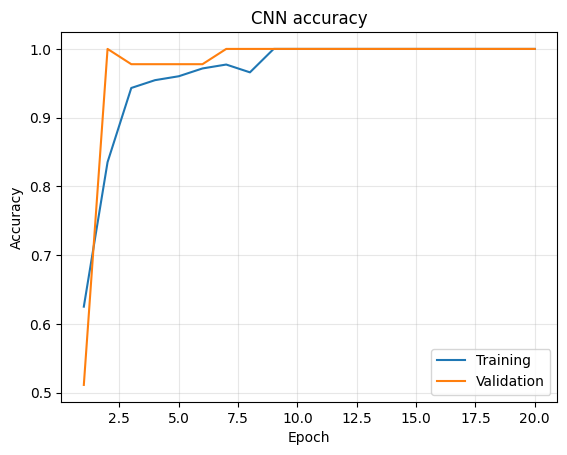

Saved in: /Users/olzhi/Desktop/Paper replication/results/final_run


In [6]:
epochs = range(1, 21)
plt.plot(epochs, history.history["accuracy"], label="Training")
plt.plot(epochs, history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{results}/accuracy_plot.png", dpi=200, bbox_inches="tight")
plt.show()

# The callback already saved the best weights, and the training cell saved
# the epoch-20 weights separately.
with open(f"{results}/training_history.json", "w") as file:
    json.dump(history.history, file)

print("Saved in:", results)